In [1]:
print("Hello World")

Hello World


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

BACKEND = ROOT / "backend"
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))

from app.config import settings
from app.services.llm import get_llm_model
from app.services.tools import web_search
from app.services.prompts import RESEARCH_SYSTEM_PROMPT

## Multi Agent

In [3]:
from app.services.agents.research.tools import web_search, scrape_url

### 1. Tools

In [7]:
query = "IPL 2026"
results = web_search.invoke({"query": query})
print(results)


[1]
Title: 2026 Indian Premier League
URL: https://en.wikipedia.org/wiki/2026_Indian_Premier_League
Snippet: # 2026 Indian Premier League. | * + Chennai Super Kings   + Kolkata Knight Riders   + Rajasthan Royals   + Royal Challengers Bengaluru   + Punjab Kings |. | * + Mumbai Indians   + Sunrisers Hyderabad   + Gujarat Titans   + Delhi Capitals   + Lucknow Super Giants |. The **2026 Indian Premier League**, also known as **IPL 19** and branded as **TATA IPL 2026**, was the 19th edition of the Indian Premier League, a professional Twenty20 cricket league. Defending champions Royal Challengers Bengaluru defeated Gujarat Titans by 5 wickets in the final to secure their second consecutive IPL title. They became the first franchise to win the IPL and the Women's Premier League "2026 Women's Premier League (cricket)") in the same year. Vaibhav Sooryavanshi of Rajasthan Royals scored the most runs (776) while Kagiso Rabada of Gujarat Titans took the most wickets (29) respectively. The Indian

In [21]:
scrape_results = scrape_url.invoke({
  "url": "https://www.britannica.com/event/Indian-Premier-League-2026"
})

In [22]:
print(scrape_results)

Indian Premier League 2026 When is the Indian Premier League 2026 scheduled to take place? Which team is the defending champion for IPL 2026? Is the Royal Challengers Bengaluru banned from IPL 2026? Is M.S. Dhoni playing in IPL 2026? Who was the most expensive player at the Indian Premier League 2026 auction? Why was Mustafizur Rahman released from his contract for the Indian Premier League 2026? What are the venues for the Indian Premier League 2026? The 19th edition of the Indian Premier League (IPL), an annual Twenty20 franchise cricket competition organized by the Board of Control for Cricket in India (BCCI), was held from March 28 to May 31, 2026. Featuring 10 teams, the tournament was hosted across different venues in India. The Royal Challengers Bengaluru (RCB) franchise, based in the city of Bengaluru, Karnataka, won its second title after beating Ahmedabad-based team, Gujarat Titans, in the final. Teams Ten IPL teams participated in the 2026 edition of the competition. | posit

### 2 Agents

In [8]:
from langchain.agents import create_agent
agent = create_agent(
    model=get_llm_model(),
    tools=[web_search],
)

In [13]:
def build_search_agent():
  agent = create_agent(
    model=get_llm_model(),
    tools=[web_search]
  )
  return agent

In [ ]:
# agent.invoke({
#   "messages":[
#     ("user", "Find recent, reliable and detailed information about {topic}")
#   ]
# })
topic = "cricket"
search_agent_response = agent.invoke({
  "messages":[
    ("user", "Find recent, reliable and detailed information about cricket")
  ]
})

In [ ]:
state = {}

In [31]:
search_results = search_agent_response['messages'][-1].content
print(search_results)
state['search_results'] = search_results

Here is a detailed, reliable overview of cricket based on current and authoritative sources (ICC, Britannica, ESPNcricinfo, Al Jazeera, and others).

---

## 1. What Is Cricket?

Cricket is a **bat-and-ball sport** played between two teams of **11 players** each. One team bats and tries to score runs, while the other bowls and fields to restrict runs and dismiss batters. The team with the most runs at the end of the match wins. It is governed globally by the **International Cricket Council (ICC)**, which has 100+ member countries, though only **12** currently play Test cricket (the longest format).

*Sources: Britannica, ICC, Wikipedia*

---

## 2. History & Origins

- **Late 16th century**: First known references to cricket in **southeast England**.
- **1611**: First record of cricket played as an adult sport (and a dictionary entry calling it a "boys' game").
- **18th century**: Cricket became a leading sport in London and the south-eastern counties; village cricket and county teams 

In [23]:
def build_scrape_agent():
  agent = create_agent(
    model=get_llm_model(),
    tools=[scrape_url]
  )
  return agent

In [28]:
scrape_agent = build_scrape_agent()

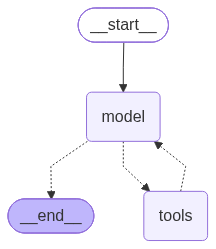

In [29]:
scrape_agent

In [32]:
reader_result = scrape_agent.invoke({
    "messages": [("user",
        f"Based on the following search results about cricket, "
        f"pick the most relevant URL and scrape it for deeper content.\n\n"
        f"Search Results:\n{state['search_results']}"
    )]
})


In [36]:
state["scraped_results"] = reader_result['messages'][-1].content

In [37]:
state

{'search_results': 'Here is a detailed, reliable overview of cricket based on current and authoritative sources (ICC, Britannica, ESPNcricinfo, Al Jazeera, and others).\n\n---\n\n## 1. What Is Cricket?\n\nCricket is a **bat-and-ball sport** played between two teams of **11 players** each. One team bats and tries to score runs, while the other bowls and fields to restrict runs and dismiss batters. The team with the most runs at the end of the match wins. It is governed globally by the **International Cricket Council (ICC)**, which has 100+ member countries, though only **12** currently play Test cricket (the longest format).\n\n*Sources: Britannica, ICC, Wikipedia*\n\n---\n\n## 2. History & Origins\n\n- **Late 16th century**: First known references to cricket in **southeast England**.\n- **1611**: First record of cricket played as an adult sport (and a dictionary entry calling it a "boys\' game").\n- **18th century**: Cricket became a leading sport in London and the south-eastern counti

In [40]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


In [41]:
## Writer Agent..

writer_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert research writer. Write clear, structured and insightful reports."),
    ("human", """Write a detailed research report on the topic below.

Topic: {topic}

Research Gathered:
{research}

Structure the report as:
- Introduction
- Key Findings (minimum 3 well-explained points)
- Conclusion
- Sources (list all URLs found in the research)

Be detailed, factual and professional."""),
])

writer_chain = writer_prompt | get_llm_model() | StrOutputParser()

In [ ]:
research_combined = (
    f"SEARCH RESULTS : \n {state['search_results']} \n\n"
    f"DETAILED SCRAPED CONTENT : \n {state['scraped_results']}"
)


In [48]:
state["report"] = writer_chain.invoke({
    "topic" : 'cricket',
    "research" : research_combined
})

In [50]:
print(state['report'])

# Research Report: Cricket

## Introduction

Cricket is a bat-and-ball sport contested between two teams of 11 players, in which one side bats to accumulate runs while the other bowls and fields to restrict scoring and dismiss batters. With origins in southeast England dating back to the late 16th century—and possibly earlier rural traditions—cricket has evolved from a informal village pastime into a globally governed professional sport under the International Cricket Council (ICC). Today, the game is played across three principal international formats (Test, One Day International, and Twenty20), enjoys immense popularity in South Asia, Australia, England, Southern Africa, and the Caribbean, and serves as a significant cultural and national identity marker in many post-colonial societies. This report synthesizes authoritative research from the ICC, Britannica, ESPNcricinfo, and related bodies to present a structured overview of cricket’s definition, history, structure, and contemporary

In [51]:
# crictic agent....
critic_prompt = ChatPromptTemplate.from_messages([
     ("system", "You are a sharp and constructive research critic. Be honest and specific."),
    ("human", """Review the research report below and evaluate it strictly.

Report:
{report}

Respond in this exact format:

Score: X/10

Strengths:
- ...
- ...

Areas to Improve:
- ...
- ...

One line verdict:
..."""),
])

critic_chain = critic_prompt | get_llm_model() | StrOutputParser()

In [52]:
state["feedback"] = critic_chain.invoke({
    "report":state['report']
})

In [54]:
print(state['feedback'])

Score: 4/10

Strengths:
- Covers a broad sweep of cricket history, formats, and governance with a clear, readable structure.
- Uses a reasonable range of sources including ICC, Britannica, and ESPNcricinfo for core factual claims.
- Correctly identifies major format differences (Test, ODI, T20) and basic playing mechanics.

Areas to Improve:
- Contains a major factual error: Sir Garfield Sobers is alive; the report falsely states he "passed" at age 89, undermining credibility.
- Relies on low-quality or inappropriate sources (Vedantu, SportMember, Wikipedia, Al Jazeera as "format overview") without critical filtering; some cited URLs are generic landing pages, not specific evidence.
- Lacks methodological transparency: no dates of source access, no distinction between authoritative law (MCC) and secondary commentary, and ranking claims ("as of 2024–2026") are vaguely framed and unverifiable.
- Conclusion overstates adaptability and future relevance without supporting data; "emotional a